Commune analysée : Région de Guelmim-Oued Noun
Total des logements urbains : None


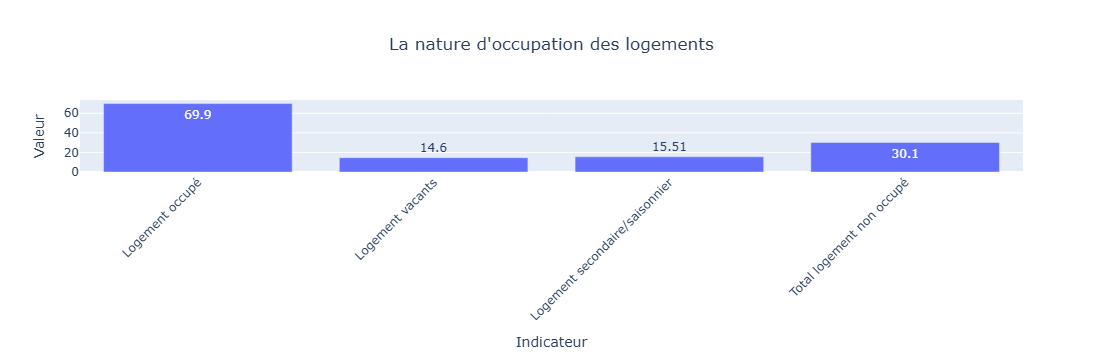

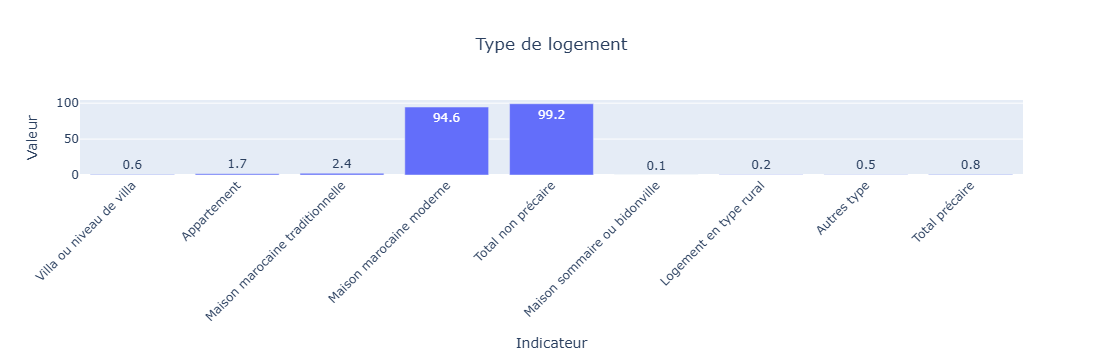

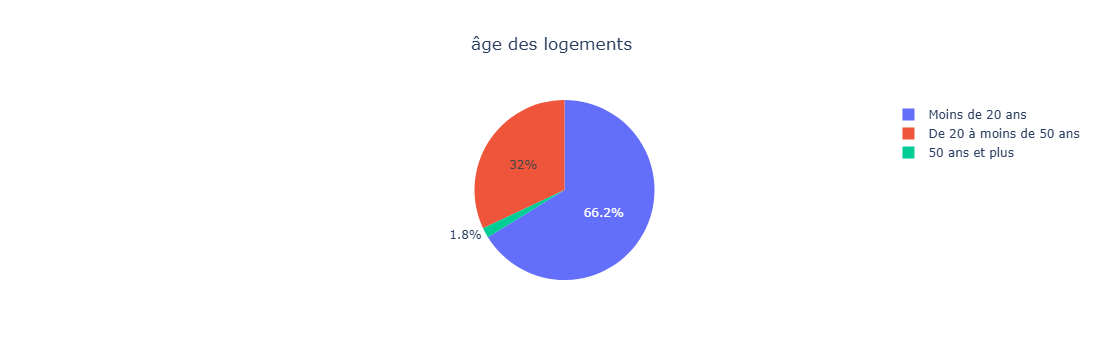

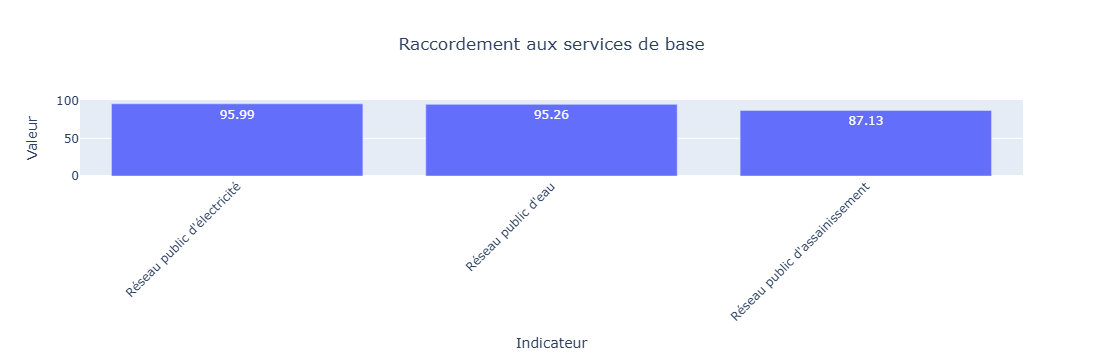

In [3]:
import pandas as pd
import plotly.express as px

df = pd.read_csv(r"../data/fichier des indicateurs parc de logements nettoye.csv")

# Nettoyage des colonnes
df.columns = (
    df.columns
    .str.replace("Indicateurs communaux du Parc logement urbain en 2024 | ", "", regex=False)
    .str.replace("|", "-", regex=False)
    .str.strip()
)

def find_col(keyword):
    for col in df.columns:
        if keyword.lower() in col.lower():
            return col
    return None

def find_cols(keyword):
    return [col for col in df.columns if keyword.lower() in col.lower()]

# Infos principales
col_commune = find_col("collectiv")
col_total = find_col("total des logements urbains")

commune = df[col_commune].iloc[0] if col_commune else "Commune inconnue"
total_logements = df[col_total].iloc[0] if col_total else None

print("Commune analysée :", commune)
print("Total des logements urbains :", total_logements)

# Fonction pour créer un graphique interactif
def plot_interactive(cols, title, chart_type="bar"):
    if not cols:
        print(f"Aucune colonne trouvée pour : {title}")
        return

    data = df[cols].iloc[0].reset_index()
    data.columns = ["Indicateur", "Valeur"]

    # Nettoyer les noms affichés
    data["Indicateur"] = data["Indicateur"].str.split("-").str[-1].str.strip()

    if chart_type == "bar":
        fig = px.bar(
            data.round(2),
            x="Indicateur",
            y="Valeur",
            text="Valeur",
            title=title
        )
    elif chart_type == "pie":
        fig = px.pie(
            data.round(2),
            names="Indicateur",
            values="Valeur",
            title=title
        )

    fig.update_layout(
        xaxis_tickangle=-45,
        title_x=0.5
    )

    fig.show()

# 1. Nature d’occupation
occupation_cols = find_cols("Nature d'occupation")

plot_interactive(
    occupation_cols,
    "La nature d'occupation des logements",
    "bar"
)

# 2. Type de logement
type_cols = [
    col for col in df.columns
    if "Type de logement %" in col and "Age" not in col
]

plot_interactive(
    type_cols,
    " Type de logement",
    "bar"
)

# 3. Âge des logements
age_cols = find_cols("Age de logement %")

plot_interactive(
    age_cols,
    " âge des logements",
    "pie"
)

# 4. Services de base
service_cols = find_cols("Raccordement aux services de base")

plot_interactive(
    service_cols,
    "Raccordement aux services de base",
    "bar"
)

# 5. Déficit quantitatif
deficit_col = find_col("déficit quantitatif")

if deficit_col:
    deficit = df[deficit_col].iloc[0]
    
df.to_csv(r"../data/outputs/analyse_Logement.csv", index=False)
    